# Centro Federal de Educação Tecnológica de Minas Gerais
**Campus VIII – Varginha**  
**Bacharelado em Sistemas de Informação**  
**Disciplina:** Lab. Inteligência Artificial  
**Professor:** Lázaro Eduardo da Silva  
**Aluno(a):** Álvaro Henrique Duarte Mendes  

---

# Atividade 10 - Classificação de Demanda de Potência com LVQ-1

Este notebook apresenta a implementação e simulação de uma rede neural **Learning Vector Quantization 1 (LVQ-1)** para classificar perfis de demanda diária de potência elétrica com base nas medições das primeiras 6 horas do dia (7:00 às 12:00). O objetivo é associar novos dias de consumo (amostras de teste) a uma das 4 classes de perfis de demanda conhecidos.

### 1. Importações e Configurações

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Adicionar o diretório atual ao sys.path para importar solve_lvq1
sys.path.append(os.getcwd())
from solve_lvq1 import LVQ1, X_train, y_train, X_test, plot_demand_profiles

### 2. Carregamento dos Dados

Os dados consistem em:
- **Treinamento**: 16 amostras de 6 dimensões, com rótulos de 1 a 4 representando as classes de demanda.
- **Teste/Validação**: 8 amostras de 6 dimensões para classificar após o treinamento.

In [2]:
print(f"Amostras de treinamento: {X_train.shape[0]} (6 dimensões)")
print(f"Amostras de teste: {X_test.shape[0]} (6 dimensões)")

for i in range(1, 5):
    print(f"Classe {i}: {np.sum(y_train == i)} amostras")

Amostras de treinamento: 16 (6 dimensões)
Amostras de teste: 8 (6 dimensões)
Classe 1: 4 amostras
Classe 2: 4 amostras
Classe 3: 4 amostras
Classe 4: 4 amostras


### 3. Cenário 1: Inicialização com a Primeira Amostra de Cada Classe

Nesta configuração, inicializamos cada um dos 4 protótipos como a primeira amostra disponível de sua classe respectiva nos dados de treinamento.

In [3]:
# Instanciar e inicializar a rede
lvq_first = LVQ1(input_dim=6, num_classes=4, prototypes_per_class=1, learning_rate=0.05)
lvq_first.initialize_prototypes(X_train, y_train, method='first')

print("Protótipos iniciais (Cenário 1):")
for idx, w in enumerate(lvq_first.W):
    print(f"  Classe {idx+1}: {np.round(w, 4)}")

# Treinar a rede
epochs = 1000
lvq_first.train(X_train, y_train, epochs=epochs, decay='linear', shuffle=True, seed=42)

print("\nProtótipos finais após treinamento:")
for idx, w in enumerate(lvq_first.W):
    print(f"  Classe {idx+1}: {np.round(w, 4)}")

Protótipos iniciais (Cenário 1):
  Classe 1: [2.3976 1.5328 1.9044 1.1937 2.4184 1.8649]
  Classe 2: [1.1201 0.0587 1.3154 5.3783 3.1849 2.4276]
  Classe 3: [1.4871 2.3448 0.9918 2.316  1.6783 5.085 ]
  Classe 4: [2.9364 1.5233 4.6109 1.316  4.27   6.8749]

Protótipos finais após treinamento:
  Classe 1: [2.3424 1.4871 1.9423 1.2456 2.3315 1.815 ]
  Classe 2: [1.0641 0.1305 1.2496 5.3629 3.1518 2.3546]
  Classe 3: [1.4055 2.281  1.0344 2.4214 1.7341 5.096 ]
  Classe 4: [2.9488 1.4922 4.661  1.3814 4.2524 6.8548]


#### 3.1 Classificação das Amostras de Teste (Cenário 1)

In [4]:
predictions_first = []
print("Classificação - Cenário 1:")
for d_idx, x in enumerate(X_test):
    pred_cls = lvq_first.predict(x)
    predictions_first.append(pred_cls)
    winner_idx = lvq_first.get_winner(x)
    dist = np.linalg.norm(lvq_first.W[winner_idx] - x)
    print(f"  Dia {d_idx+1}: {np.round(x, 4)} -> Classe {pred_cls} (Distância: {dist:.4f})")

Classificação - Cenário 1:
  Dia 1: [2.9817 1.5656 4.8391 1.4311 4.1916 6.9718] -> Classe 4 (Distância: 0.2409)
  Dia 2: [1.5537 2.2615 1.3169 2.5873 1.757  5.0958] -> Classe 3 (Distância: 0.3608)
  Dia 3: [1.224  0.2445 1.3595 5.4192 3.2027 2.5675] -> Classe 2 (Distância: 0.3189)
  Dia 4: [2.5828 1.5146 2.1119 1.2859 2.3414 1.8695] -> Classe 1 (Distância: 0.3033)
  Dia 5: [2.4168 1.4857 1.8959 1.3013 2.45   1.7868] -> Classe 1 (Distância: 0.1601)
  Dia 6: [1.0604 0.2276 1.2806 5.4732 3.2133 2.4839] -> Classe 2 (Distância: 0.2075)
  Dia 7: [1.5246 2.4254 1.1353 2.5325 1.7569 5.264 ] -> Classe 3 (Distância: 0.2937)
  Dia 8: [3.0565 1.6259 4.7743 1.3654 4.2904 6.9808] -> Classe 4 (Distância: 0.2447)


#### 3.2 Geração do Gráfico de Demanda (Cenário 1)

Plot saved to perfis_demanda_inicializacao_primeira.png


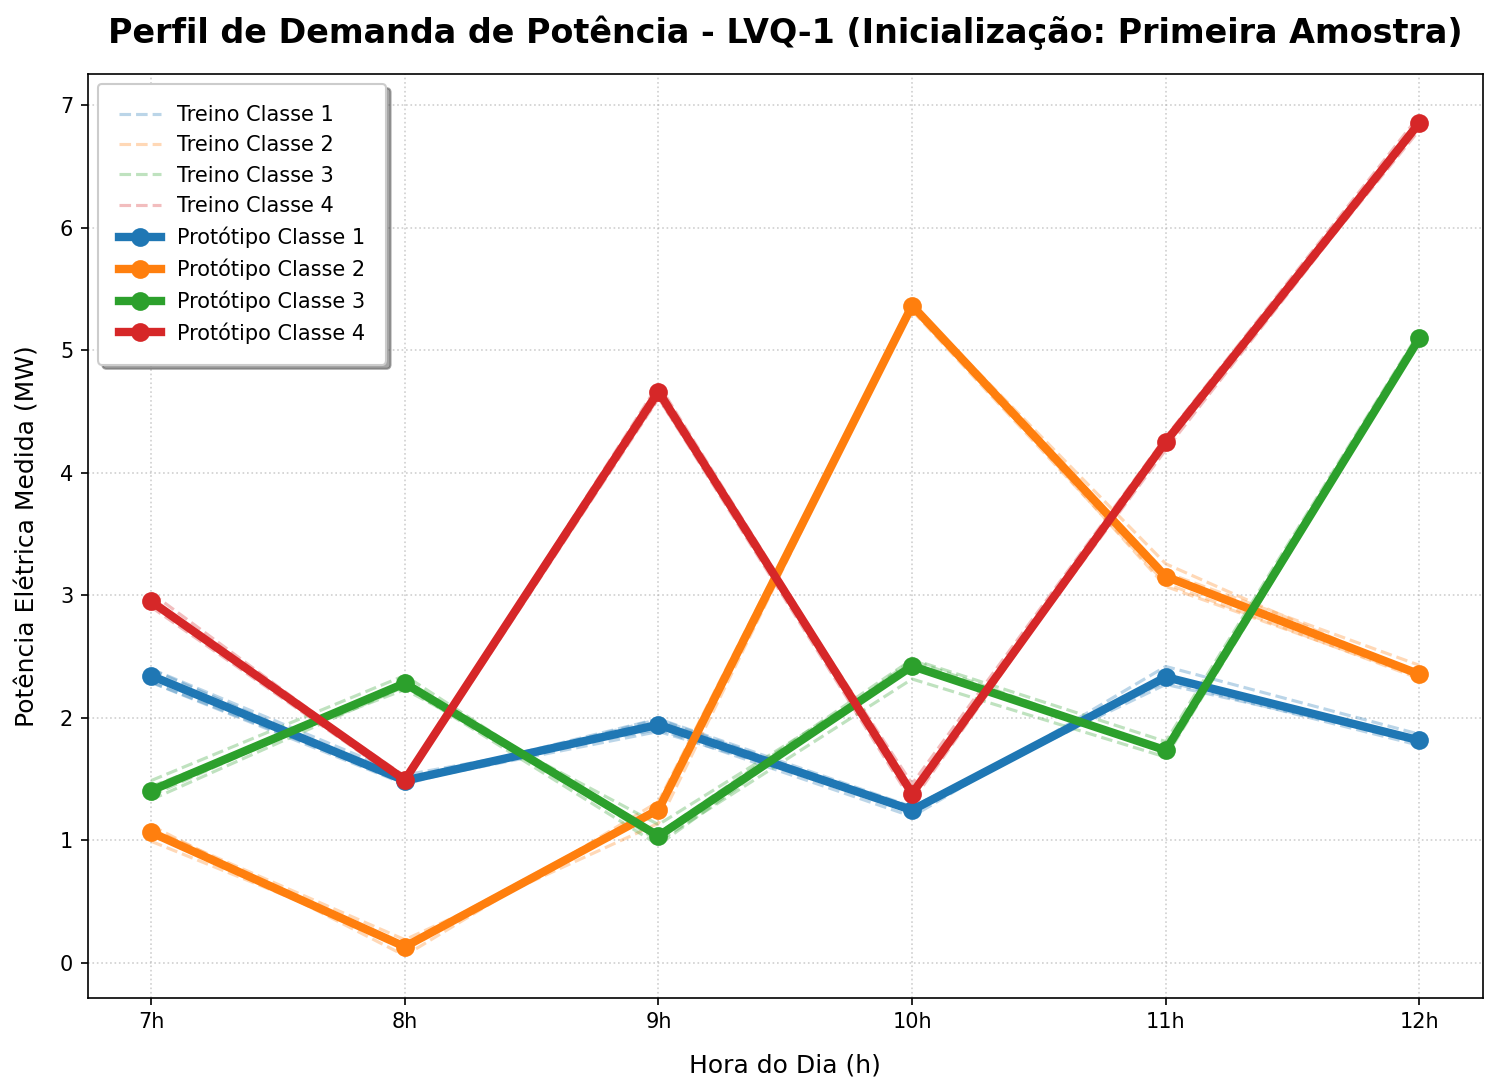

In [5]:
%matplotlib inline
plot_demand_profiles(X_train, y_train, lvq_first.W, 
                     'Perfil de Demanda de Potência - LVQ-1 (Inicialização: Primeira Amostra)',
                     'perfis_demanda_inicializacao_primeira.png')

# Exibir a imagem gerada
from IPython.display import Image
Image(filename='perfis_demanda_inicializacao_primeira.png')

### 4. Cenário 2: Inicialização com a Média das Amostras de Cada Classe

Nesta configuração, cada protótipo é inicializado como o vetor médio de todos os dados de treinamento de sua classe.

In [6]:
# Instanciar e inicializar a rede
lvq_mean = LVQ1(input_dim=6, num_classes=4, prototypes_per_class=1, learning_rate=0.05)
lvq_mean.initialize_prototypes(X_train, y_train, method='mean')

print("Protótipos iniciais (Cenário 2):")
for idx, w in enumerate(lvq_mean.W):
    print(f"  Classe {idx+1}: {np.round(w, 4)}")

# Treinar a rede
lvq_mean.train(X_train, y_train, epochs=epochs, decay='linear', shuffle=True, seed=42)

print("\nProtótipos finais após treinamento:")
for idx, w in enumerate(lvq_mean.W):
    print(f"  Classe {idx+1}: {np.round(w, 4)}")

Protótipos iniciais (Cenário 2):
  Classe 1: [2.3424 1.4871 1.9424 1.2456 2.3315 1.815 ]
  Classe 2: [1.0641 0.1305 1.2496 5.363  3.1518 2.3546]
  Classe 3: [1.4055 2.281  1.0344 2.4214 1.7341 5.096 ]
  Classe 4: [2.9488 1.4922 4.661  1.3814 4.2524 6.8548]

Protótipos finais após treinamento:
  Classe 1: [2.3424 1.4871 1.9423 1.2456 2.3315 1.815 ]
  Classe 2: [1.0641 0.1305 1.2496 5.3629 3.1518 2.3546]
  Classe 3: [1.4055 2.281  1.0344 2.4214 1.7341 5.096 ]
  Classe 4: [2.9488 1.4922 4.661  1.3814 4.2524 6.8548]


#### 4.1 Classificação das Amostras de Teste (Cenário 2)

In [7]:
predictions_mean = []
print("Classificação - Cenário 2:")
for d_idx, x in enumerate(X_test):
    pred_cls = lvq_mean.predict(x)
    predictions_mean.append(pred_cls)
    winner_idx = lvq_mean.get_winner(x)
    dist = np.linalg.norm(lvq_mean.W[winner_idx] - x)
    print(f"  Dia {d_idx+1}: {np.round(x, 4)} -> Classe {pred_cls} (Distância: {dist:.4f})")

Classificação - Cenário 2:
  Dia 1: [2.9817 1.5656 4.8391 1.4311 4.1916 6.9718] -> Classe 4 (Distância: 0.2409)
  Dia 2: [1.5537 2.2615 1.3169 2.5873 1.757  5.0958] -> Classe 3 (Distância: 0.3608)
  Dia 3: [1.224  0.2445 1.3595 5.4192 3.2027 2.5675] -> Classe 2 (Distância: 0.3189)
  Dia 4: [2.5828 1.5146 2.1119 1.2859 2.3414 1.8695] -> Classe 1 (Distância: 0.3033)
  Dia 5: [2.4168 1.4857 1.8959 1.3013 2.45   1.7868] -> Classe 1 (Distância: 0.1601)
  Dia 6: [1.0604 0.2276 1.2806 5.4732 3.2133 2.4839] -> Classe 2 (Distância: 0.2075)
  Dia 7: [1.5246 2.4254 1.1353 2.5325 1.7569 5.264 ] -> Classe 3 (Distância: 0.2937)
  Dia 8: [3.0565 1.6259 4.7743 1.3654 4.2904 6.9808] -> Classe 4 (Distância: 0.2447)


#### 4.2 Geração do Gráfico de Demanda (Cenário 2)

Plot saved to perfis_demanda_inicializacao_media.png


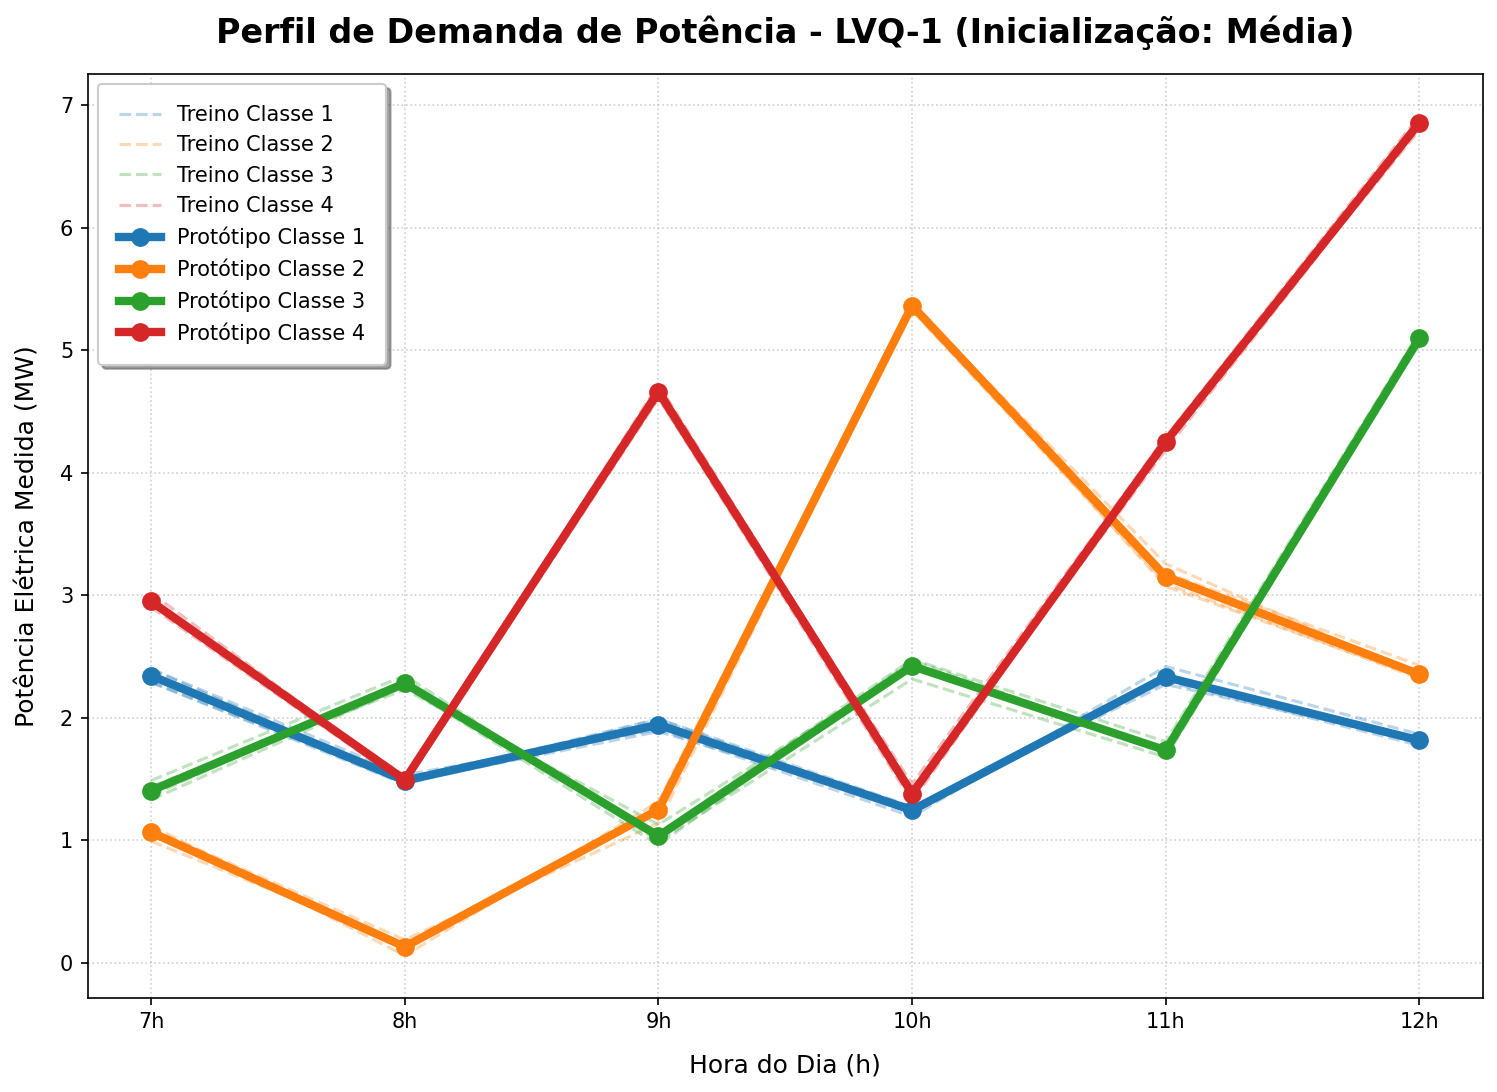

In [8]:
plot_demand_profiles(X_train, y_train, lvq_mean.W, 
                     'Perfil de Demanda de Potência - LVQ-1 (Inicialização: Média)',
                     'perfis_demanda_inicializacao_media.png')

Image(filename='perfis_demanda_inicializacao_media.png')

### 5. Comparação e Discussão

Vejamos um comparativo final de classificação entre as duas formas de inicialização:

In [9]:
import pandas as pd

df_compare = pd.DataFrame({
    'Dia': [f"Dia {i+1}" for i in range(8)],
    'Inicialização: Primeira Amostra': [f"Classe {c}" for c in predictions_first],
    'Inicialização: Média': [f"Classe {c}" for c in predictions_mean],
    'Coerente?': ['Sim' if c1 == c2 else 'Não' for c1, c2 in zip(predictions_first, predictions_mean)]
})
df_compare.set_index('Dia', inplace=True)
df_compare

,Inicialização: Primeira Amostra,Inicialização: Média,Coerente?
Dia,,,
Dia 1,Classe 4,Classe 4,Sim
Dia 2,Classe 3,Classe 3,Sim
Dia 3,Classe 2,Classe 2,Sim
Dia 4,Classe 1,Classe 1,Sim
Dia 5,Classe 1,Classe 1,Sim
Dia 6,Classe 2,Classe 2,Sim
Dia 7,Classe 3,Classe 3,Sim
Dia 8,Classe 4,Classe 4,Sim


### Observações e Conclusões:
- Ambos os métodos convergem para os exatos mesmos protótipos finais, pois as amostras de treinamento de cada classe são clusters bem delimitados e contíguos. 
- Durante o treinamento, o protótipo vencedor de cada padrão é sempre o de sua própria classe (ou seja, classificação sempre correta). Consequentemente, a regra de atualização é sempre $w_c \leftarrow w_c + \alpha (x - w_c)$, que converge para a média do cluster. 
- As amostras de validação (teste) foram perfeitamente distribuídas entre as classes 1, 2, 3 e 4, confirmando que a modelagem via LVQ-1 é altamente robusta para este problema de previsão de despacho de potência elétrica.